# Parkinson ENS Challenge — v3 : optimisations avancées

**Améliorations par rapport à v2 (RMSE 3.7703) :**
- Nouvelles features : pente du LEDD, coefficient de variation, valeurs baseline/last, features de rang intra-cohorte
- Early stopping (4 000 itérations max au lieu de 1 500/800/800)
- Seed averaging (graines 42 / 1 / 7)
- Target encoding intra-fold (sans fuite)
- Stacking Ridge sur les prédictions OOF
- Optimisation automatique des poids du blend final

> **Durée estimée : 30–50 min selon la machine.**

## 1. Imports

In [2]:
import sys
print(sys.executable)

import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm", "xgboost", "catboost"])

C:\Users\Bonjour\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


0

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 50)
np.random.seed(42)

SEEDS   = [42, 1, 7]   # seed averaging
N_FOLDS = 5

C:\Users\Bonjour\AppData\Local\Temp\ipykernel_17892\2654603863.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 2. Chargement

In [4]:
X_train = pd.read_csv("../data/X_train_6ZIKlTY.csv")
y_train = pd.read_csv("../data/y_train_lXj6X5y.csv")
X_test  = pd.read_csv("../data/X_test_oiZ2ukx.csv")

# Copies brutes pour l'interpolation et les features baseline
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print(X_train.isnull().sum())

X_train: (55603, 12) | X_test: (23672, 13)
Index                        0
patient_id                   0
cohort                       0
sexM                         0
gene                     17958
age_at_diagnosis          2830
age                          0
ledd                     20593
time_since_intake_on     25940
time_since_intake_off    43828
on                       16659
off                      23407
dtype: int64


## 3. Feature Engineering

### 3.1 time_since_diagnosis + encodage catégoriel + indicateurs NaN

In [5]:
X_train["time_since_diagnosis"] = X_train["age"] - X_train["age_at_diagnosis"]

le_cohort = LabelEncoder()
le_gene   = LabelEncoder()
X_train["cohort"] = le_cohort.fit_transform(X_train["cohort"])
X_test["cohort"]  = le_cohort.transform(X_test["cohort"])
X_train["gene"]   = le_gene.fit_transform(X_train["gene"].fillna("Unknown"))
X_test["gene"]    = le_gene.transform(X_test["gene"].fillna("Unknown"))

for c in ["off", "on", "ledd", "age_at_diagnosis"]:
    X_train[f"{c}_missing"] = X_train[c].isnull().astype(int)
    X_test[f"{c}_missing"]  = X_test[c].isnull().astype(int)

X_train["a_score_off_mesure"] = X_train["time_since_intake_off"].isnull().astype(int)
X_test["a_score_off_mesure"]  = X_test["time_since_intake_off"].isnull().astype(int)

### 3.2 Écart à la moyenne patient (AVANT imputation)

In [6]:
for c in ["off", "on"]:
    X_train[f"{c}_dev_from_pat_mean"] = (
        X_train[c] - X_train.groupby("patient_id")[c].transform("mean"))
    X_test[f"{c}_dev_from_pat_mean"] = (
        X_test[c] - X_test.groupby("patient_id")[c].transform("mean"))

### 3.3 Pentes de progression par patient : off, on **et ledd** (nouveau)

In [7]:
def slope(sub_age, sub_val):
    mask = sub_val.notna() & sub_age.notna()
    if mask.sum() < 2:
        return np.nan
    a, v = sub_age[mask].values, sub_val[mask].values
    if np.ptp(a) == 0:
        return 0.0
    return np.polyfit(a, v, 1)[0]


for df in (X_train, X_test):
    sl = df.groupby("patient_id").apply(
        lambda g: pd.Series({
            "off_slope":  slope(g["age"], g["off"]),
            "on_slope":   slope(g["age"], g["on"]),
            "ledd_slope": slope(g["age"], g["ledd"]),   # NOUVEAU
        })
    ).reset_index()
    df[["off_slope", "on_slope", "ledd_slope"]] = (
        df.merge(sl, on="patient_id", how="left")[["off_slope", "on_slope", "ledd_slope"]].values
    )

for c in ["off_slope", "on_slope", "ledd_slope"]:
    med = X_train[c].median()
    X_train[c] = X_train[c].fillna(med)
    X_test[c]  = X_test[c].fillna(med)

C:\Users\Bonjour\AppData\Local\Temp\ipykernel_17892\2244585550.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sl = df.groupby("patient_id").apply(
C:\Users\Bonjour\AppData\Local\Temp\ipykernel_17892\2244585550.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sl = df.groupby("patient_id").apply(


### 3.4 Stats patient (mean / std / min / max / median) + **CV** + imputation intra-patient

In [8]:
for c in ["off", "on"]:
    for df in (X_train, X_test):
        stats = df.groupby("patient_id")[c].agg(["mean", "std", "min", "max", "median"])
        stats.columns = [f"{c}_pat_{s}" for s in stats.columns]
        df[list(stats.columns)] = df.merge(stats, on="patient_id", how="left")[list(stats.columns)].values

    # Coefficient de variation (dispersion relative) — NOUVEAU
    X_train[f"{c}_pat_cv"] = (
        X_train[f"{c}_pat_std"] / (X_train[f"{c}_pat_mean"].abs() + 1))
    X_test[f"{c}_pat_cv"] = (
        X_test[f"{c}_pat_std"] / (X_test[f"{c}_pat_mean"].abs() + 1))

    # Imputation intra-patient
    X_train[c] = X_train.groupby("patient_id")[c].transform(lambda s: s.fillna(s.mean()))
    X_test[c]  = X_test.groupby("patient_id")[c].transform(lambda s: s.fillna(s.mean()))
    med = X_train[c].median()
    X_train[c] = X_train[c].fillna(med)
    X_test[c]  = X_test[c].fillna(med)

# Stats LEDD patient
for df in (X_train, X_test):
    stats = df.groupby("patient_id")["ledd"].agg(["mean", "std"])
    stats.columns = ["ledd_pat_mean", "ledd_pat_std"]
    df[["ledd_pat_mean", "ledd_pat_std"]] = (
        df.merge(stats, on="patient_id", how="left")[["ledd_pat_mean", "ledd_pat_std"]].values
    )

### 3.5 Valeurs baseline et last par patient 

La première et la dernière mesure connue de `off`/`on` par patient, calculées sur les données **brutes** (avant imputation), comme proxy de l'état initial et de l'état terminal de la maladie.

In [9]:
for df, raw in [(X_train, X_train_raw), (X_test, X_test_raw)]:
    for c in ["off", "on"]:
        # Première valeur non-NaN par patient
        first_val = (raw.groupby("patient_id")[c]
                     .apply(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan))
        last_val  = (raw.groupby("patient_id")[c]
                     .apply(lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan))
        df[f"{c}_baseline"] = df["patient_id"].map(first_val)
        df[f"{c}_last"]     = df["patient_id"].map(last_val)
        df[f"{c}_total_change"] = df[f"{c}_last"] - df[f"{c}_baseline"]
        # Remplissage par la moyenne patient si NaN
        for col in [f"{c}_baseline", f"{c}_last", f"{c}_total_change"]:
            df[col] = df[col].fillna(df[f"{c}_pat_mean"])

### 3.6 Trajectoire temporelle

In [10]:
for df in (X_train, X_test):
    df["visit_num"]              = df.groupby("patient_id").cumcount()
    df["nb_visites_patient"]     = df.groupby("patient_id")["age"].transform("count")
    df["age_first_visit"]        = df.groupby("patient_id")["age"].transform("min")
    df["time_since_first_visit"] = df["age"] - df["age_first_visit"]
    df["visit_frac"]             = df["visit_num"] / (df["nb_visites_patient"] - 1).clip(lower=1)

### 3.7 Ratios et interactions

In [11]:
for df in (X_train, X_test):
    df["dose_per_year"]             = df["ledd"] / (df["time_since_diagnosis"] + 1)
    df["on_off_ratio"]              = df["on"] / (df["off"] + 1)
    df["age_diagnosis_interaction"] = df["age"] * df["time_since_diagnosis"]
    df["off_minus_on"]              = df["off"] - df["on"]
    df["ledd_dev_from_pat_mean"]    = df["ledd"] - df["ledd_pat_mean"]
    df["diag_frac_of_life"]         = df["time_since_diagnosis"] / (df["age"] + 1)
    df["intake_gap"]                = df["time_since_intake_off"] - df["time_since_intake_on"]
    df["off_pat_range"]             = df["off_pat_max"] - df["off_pat_min"]
    df["on_pat_range"]              = df["on_pat_max"] - df["on_pat_min"]
    df["off_ledd_interaction"]      = df["off"] * df["ledd"]          # NOUVEAU
    df["on_ledd_interaction"]       = df["on"]  * df["ledd"]          # NOUVEAU

### 3.8 Voisinage (ordre 1 et 2) + timing inter-visites + dérivées locales

In [12]:
for df in (X_train, X_test):
    df["__pid"] = df["patient_id"].values
    for c in ["off", "on"]:
        df[f"{c}_prev"]  = df.groupby("__pid")[c].shift(1)
        df[f"{c}_next"]  = df.groupby("__pid")[c].shift(-1)
        df[f"{c}_prev2"] = df.groupby("__pid")[c].shift(2)
        df[f"{c}_next2"] = df.groupby("__pid")[c].shift(-2)

    df["age_prev"] = df.groupby("__pid")["age"].shift(1)
    df["age_next"] = df.groupby("__pid")["age"].shift(-1)
    df["gap_prev"] = (df["age"] - df["age_prev"]).fillna(0)
    df["gap_next"] = (df["age_next"] - df["age"]).fillna(0)
    df.drop(columns=["age_prev", "age_next", "__pid"], inplace=True)

    for c in ["off_prev", "off_next", "off_prev2", "off_next2"]:
        df[c] = df[c].fillna(df["off_pat_mean"])
    for c in ["on_prev", "on_next", "on_prev2", "on_next2"]:
        df[c] = df[c].fillna(df["on_pat_mean"])

    df["off_neigh_mean"] = df[["off_prev", "off_next"]].mean(axis=1)
    df["on_neigh_mean"]  = df[["on_prev",  "on_next"]].mean(axis=1)
    df["off_delta_prev"] = df["off"] - df["off_prev"]
    df["off_delta_next"] = df["off_next"] - df["off"]
    df["on_delta_prev"]  = df["on"] - df["on_prev"]

### 3.9 Projection par pente + interpolation linéaire intra-patient

In [13]:
for df, raw in [(X_train, X_train_raw), (X_test, X_test_raw)]:
    mean_age = df.groupby("patient_id")["age"].transform("mean")
    df["off_slope_proj"] = df["off_pat_mean"] + df["off_slope"] * (df["age"] - mean_age)
    df["on_slope_proj"]  = df["on_pat_mean"]  + df["on_slope"]  * (df["age"] - mean_age)

    for c in ["off", "on"]:
        interp = (raw.groupby("patient_id", group_keys=False)[c]
                  .apply(lambda s: s.interpolate(method="linear", limit_direction="both")))
        df[f"{c}_interp"]    = interp.values
        df[f"{c}_vs_interp"] = df[c] - df[f"{c}_interp"]
        df[f"{c}_interp"]    = df[f"{c}_interp"].fillna(df[f"{c}_pat_mean"])

### 3.10 Features de rang intra-cohorte 

Où se situe ce patient par rapport aux autres de la **même cohorte** ? Ces features capturent des effets de population (un score de 40 peut être normal dans la cohorte B et sévère dans la cohorte A).

In [14]:
for df in (X_train, X_test):
    # Rang percentile du score OFF moyen du patient dans sa cohorte
    df["off_rank_in_cohort"] = (df.groupby("cohort")["off_pat_mean"]
                                  .transform(lambda s: s.rank(pct=True)))
    df["on_rank_in_cohort"]  = (df.groupby("cohort")["on_pat_mean"]
                                  .transform(lambda s: s.rank(pct=True)))

    # Z-score de l'âge dans la cohorte
    df["age_zscore_cohort"] = (df.groupby("cohort")["age"]
                                 .transform(lambda s: (s - s.mean()) / (s.std() + 1e-9)))

    # Rang du LEDD moyen dans la cohorte
    df["ledd_rank_in_cohort"] = (df.groupby("cohort")["ledd_pat_mean"]
                                   .transform(lambda s: s.rank(pct=True)))

    # Écart du off actuel par rapport à la moyenne de la cohorte (z-score)
    df["off_zscore_cohort"] = (df.groupby("cohort")["off"]
                                  .transform(lambda s: (s - s.mean()) / (s.std() + 1e-9)))

print("Nombre de features (avant finalisation) :",
      X_train.drop(columns=["Index","patient_id"], errors="ignore").shape[1])

Nombre de features (avant finalisation) : 83


### 3.11 Finalisation

In [15]:
groups     = X_train["patient_id"].values
X_test_idx = X_test["Index"].values

X = X_train.drop(columns=["Index", "patient_id"])
X_test_final = X_test.drop(columns=["Index", "patient_id"])
X_test_final = X_test_final[X.columns]

y = y_train["target"]

print("X_train shape :", X.shape)
print("X_test  shape :", X_test_final.shape)
print("NaN dans X_train :", X.isnull().sum().sum())
print("NaN dans X_test  :", X_test_final.isnull().sum().sum())

X_train shape : (55603, 83)
X_test  shape : (23672, 83)
NaN dans X_train : 362842
NaN dans X_test  : 151129


## 4. Validation : GroupKFold par patient_id

In [16]:
gkf    = GroupKFold(n_splits=N_FOLDS)
splits = list(gkf.split(X, y, groups=groups))

def rmse(a, b):
    return np.sqrt(mean_squared_error(np.asarray(a), np.asarray(b)))

## 5. Baselines rapides (1 fold — comparaison)

In [17]:
tr_idx, va_idx = splits[0]
imp = SimpleImputer(strategy="median")
Xtr_imp = pd.DataFrame(imp.fit_transform(X.iloc[tr_idx]), columns=X.columns)
Xva_imp = pd.DataFrame(imp.transform(X.iloc[va_idx]),     columns=X.columns)
ytr_b, yva_b = y.iloc[tr_idx].values, y.iloc[va_idx].values

lr = LinearRegression().fit(Xtr_imp, ytr_b)
print("Linear Regression RMSE :", rmse(yva_b, lr.predict(Xva_imp)))

rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42).fit(Xtr_imp, ytr_b)
print("Random Forest     RMSE :", rmse(yva_b, rf.predict(Xva_imp)))

Linear Regression RMSE : 4.553317953816429
Random Forest     RMSE : 3.9774937395552787


## 6. Entraînement principal : early stopping + seed averaging + target encoding

**3 nouveautés par rapport à v2 :**
1. **Early stopping** : jusqu'à 4 000 arbres, arrêt dès que la validation ne s'améliore plus pendant 150 rounds.
2. **Seed averaging** : chaque modèle est entraîné avec 3 graines différentes ; les prédictions sont moyennées pour réduire la variance.
3. **Target encoding intra-fold** : pour chaque fold, on encode `cohort` et `gene` par la moyenne de la **cible dans le fold d'entraînement** (aucune fuite car la validation n'est jamais vue). CatBoost n'en a pas besoin (il fait ça nativement).

In [18]:
n_seeds = len(SEEDS)

oof_lgb  = np.zeros(len(y))
oof_xgb  = np.zeros(len(y))
oof_cat  = np.zeros(len(y))
pred_lgb = np.zeros(len(X_test_final))
pred_xgb = np.zeros(len(X_test_final))
pred_cat = np.zeros(len(X_test_final))


def add_target_encoding(Xtr_f, Xva_f, Xte_f, ytr_f, y_full, X_full):
    """
    Ajoute des features de target encoding pour cohort, gene, cohort×gene.
    Calculées uniquement sur le fold d'entraînement (pas de fuite).
    Le test utilise la moyenne sur l'ensemble du train.
    """
    Xtr_f, Xva_f, Xte_f = Xtr_f.copy(), Xva_f.copy(), Xte_f.copy()
    global_mean = ytr_f.mean()

    for col in ["cohort", "gene"]:
        te = pd.Series(ytr_f.values, index=Xtr_f.index).groupby(Xtr_f[col]).mean()
        Xtr_f[f"{col}_te"] = Xtr_f[col].map(te).fillna(global_mean)
        Xva_f[f"{col}_te"] = Xva_f[col].map(te).fillna(global_mean)
        te_full = pd.Series(y_full.values, index=X_full.index).groupby(X_full[col]).mean()
        Xte_f[f"{col}_te"] = Xte_f[col].map(te_full).fillna(y_full.mean())

    # Interaction cohort × gene
    Xtr_f["__cg"] = Xtr_f["cohort"].astype(str) + "_" + Xtr_f["gene"].astype(str)
    Xva_f["__cg"] = Xva_f["cohort"].astype(str) + "_" + Xva_f["gene"].astype(str)
    Xte_f["__cg"] = Xte_f["cohort"].astype(str) + "_" + Xte_f["gene"].astype(str)
    te_cg = pd.Series(ytr_f.values, index=Xtr_f.index).groupby(Xtr_f["__cg"]).mean()
    te_cg_full = pd.Series(y_full.values, index=X_full.index).groupby(
        (X_full["cohort"].astype(str) + "_" + X_full["gene"].astype(str))).mean()
    Xtr_f["cohort_gene_te"] = Xtr_f["__cg"].map(te_cg).fillna(global_mean)
    Xva_f["cohort_gene_te"] = Xva_f["__cg"].map(te_cg).fillna(global_mean)
    Xte_f["cohort_gene_te"] = Xte_f["__cg"].map(te_cg_full).fillna(y_full.mean())
    for df in (Xtr_f, Xva_f, Xte_f):
        df.drop(columns="__cg", inplace=True)

    return Xtr_f, Xva_f, Xte_f


for seed in SEEDS:
    print(f"\n{'='*50}\n  SEED {seed}\n{'='*50}")
    for fold_i, (tr, va) in enumerate(splits):
        print(f"  Fold {fold_i+1}/{N_FOLDS}...", end=" ", flush=True)

        Xtr_f, ytr_f = X.iloc[tr].copy(), y.iloc[tr]
        Xva_f, yva_f = X.iloc[va].copy(), y.iloc[va]
        Xte_f        = X_test_final.copy()

        # --- Target encoding intra-fold ---
        Xtr_f, Xva_f, Xte_f = add_target_encoding(Xtr_f, Xva_f, Xte_f, ytr_f, y, X)

        # --- LightGBM ---
        m_lgb = lgb.LGBMRegressor(
            n_estimators=4000, num_leaves=63, learning_rate=0.02,
            subsample=0.8, colsample_bytree=0.7, min_child_samples=20,
            reg_lambda=1.0, random_state=seed, verbosity=-1)
        m_lgb.fit(
            Xtr_f, ytr_f,
            eval_set=[(Xva_f, yva_f)],
            callbacks=[lgb.early_stopping(150, verbose=False),
                       lgb.log_evaluation(period=-1)])
        oof_lgb[va]  += m_lgb.predict(Xva_f) / n_seeds
        pred_lgb     += m_lgb.predict(Xte_f) / (n_seeds * N_FOLDS)

        # --- XGBoost ---
        m_xgb = XGBRegressor(
            n_estimators=4000, max_depth=5, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.7, reg_lambda=1.0,
            random_state=seed, early_stopping_rounds=150,
            eval_metric="rmse")
        m_xgb.fit(Xtr_f, ytr_f, eval_set=[(Xva_f, yva_f)], verbose=False)
        oof_xgb[va]  += m_xgb.predict(Xva_f) / n_seeds
        pred_xgb     += m_xgb.predict(Xte_f) / (n_seeds * N_FOLDS)

        # --- CatBoost ---
        m_cat = CatBoostRegressor(
            iterations=4000, depth=6, learning_rate=0.04, l2_leaf_reg=3.0,
            random_state=seed, verbose=False,
            cat_features=["cohort", "gene"],
            early_stopping_rounds=150)
        m_cat.fit(Xtr_f, ytr_f, eval_set=[(Xva_f, yva_f)])
        oof_cat[va]  += m_cat.predict(Xva_f) / n_seeds
        pred_cat     += m_cat.predict(Xte_f) / (n_seeds * N_FOLDS)

        print(f"LGB={rmse(yva_f, oof_lgb[va]*n_seeds):.4f}")


print("\n=== RMSE OOF finaux (seed-averaged) ===")
print(f"LightGBM : {rmse(y, oof_lgb):.4f}")
print(f"XGBoost  : {rmse(y, oof_xgb):.4f}")
print(f"CatBoost : {rmse(y, oof_cat):.4f}")


  SEED 42
  Fold 1/5... LGB=3.6033
  Fold 2/5... LGB=3.6499
  Fold 3/5... LGB=3.6084
  Fold 4/5... LGB=3.5513
  Fold 5/5... LGB=3.7303

  SEED 1
  Fold 1/5... LGB=40.7595
  Fold 2/5... LGB=40.4968
  Fold 3/5... LGB=40.6362
  Fold 4/5... LGB=40.9346
  Fold 5/5... LGB=41.1168

  SEED 7
  Fold 1/5... LGB=81.3618
  Fold 2/5... LGB=80.9296
  Fold 3/5... LGB=81.0639
  Fold 4/5... LGB=81.4110
  Fold 5/5... LGB=81.9626

=== RMSE OOF finaux (seed-averaged) ===
LightGBM : 3.6164
XGBoost  : 3.6444
CatBoost : 3.6095


## 7. Stacking Ridge sur les prédictions OOF

Au lieu de combiner les trois modèles avec des poids fixes, on entraîne un méta-modèle Ridge sur leurs prédictions OOF. `positive=True` force des poids positifs (ce qui a du sens : on ne veut pas de poids négatifs entre des modèles similaires).

In [19]:
Z_oof  = np.column_stack([oof_lgb, oof_xgb, oof_cat])
Z_test = np.column_stack([pred_lgb, pred_xgb, pred_cat])

meta = Ridge(alpha=1.0, positive=True)
meta.fit(Z_oof, y)

print(f"Stacking Ridge RMSE : {rmse(y, meta.predict(Z_oof)):.4f}")
print(f"  coefs LGB={meta.coef_[0]:.3f}  XGB={meta.coef_[1]:.3f}  CAT={meta.coef_[2]:.3f}  intercept={meta.intercept_:.3f}")

y_pred_stacked = meta.predict(Z_test)

Stacking Ridge RMSE : 3.5735
  coefs LGB=0.445  XGB=0.005  CAT=0.555  intercept=-0.193


## 8. Optimisation du blend (convex weights)

In [20]:
best_rmse, best_w = 1e9, None

for wl in np.arange(0, 1.01, 0.05):
    for wx in np.arange(0, 1.01 - wl, 0.05):
        wc = round(1 - wl - wx, 3)
        if wc < -1e-9:
            continue
        r = rmse(y, wl * oof_lgb + wx * oof_xgb + wc * oof_cat)
        if r < best_rmse:
            best_rmse, best_w = r, (round(wl, 3), round(wx, 3), wc)

W_LGB, W_XGB, W_CAT = best_w
blend_oof  = W_LGB * oof_lgb  + W_XGB * oof_xgb  + W_CAT * oof_cat
blend_test = W_LGB * pred_lgb + W_XGB * pred_xgb + W_CAT * pred_cat

r_stack = rmse(y, meta.predict(Z_oof))
r_blend = rmse(y, blend_oof)

print("\n=== Comparaison des méthodes de combinaison ===")
print(f"Blend v2 (0.70/0.00/0.30)  : 3.7703  (référence)")
print(f"Blend optimal ({W_LGB}/{W_XGB}/{W_CAT}) : {r_blend:.4f}")
print(f"Stacking Ridge              : {r_stack:.4f}")

# Choisir la meilleure méthode
if r_stack < r_blend:
    print("\n→ Stacking Ridge retenu")
    y_pred_final = y_pred_stacked
else:
    print("\n→ Blend pondéré retenu")
    y_pred_final = blend_test


=== Comparaison des méthodes de combinaison ===
Blend v2 (0.70/0.00/0.30)  : 3.7703  (référence)
Blend optimal (0.5/0.0/0.5) : 3.5742
Stacking Ridge              : 3.5735

→ Stacking Ridge retenu


## 9. Soumission finale

In [21]:
submission = pd.DataFrame({"Index": X_test_idx, "target": y_pred_final})
submission.to_csv("../data/submissionx.csv", index=False)
print(f"Fichier écrit : data/submissionx.csv  ({len(submission)} lignes)")
submission.head(10)

Fichier écrit : data/submissionx.csv  (23672 lignes)


,Index,target
0,0,42.723179
1,1,44.829277
2,2,46.034338
3,3,48.713801
4,4,50.105946
5,5,52.081336
6,6,53.002084
7,7,54.288613
8,8,56.255714
9,9,57.136567


## 10. Importance des features (LightGBM — dernier fold, dernière seed)

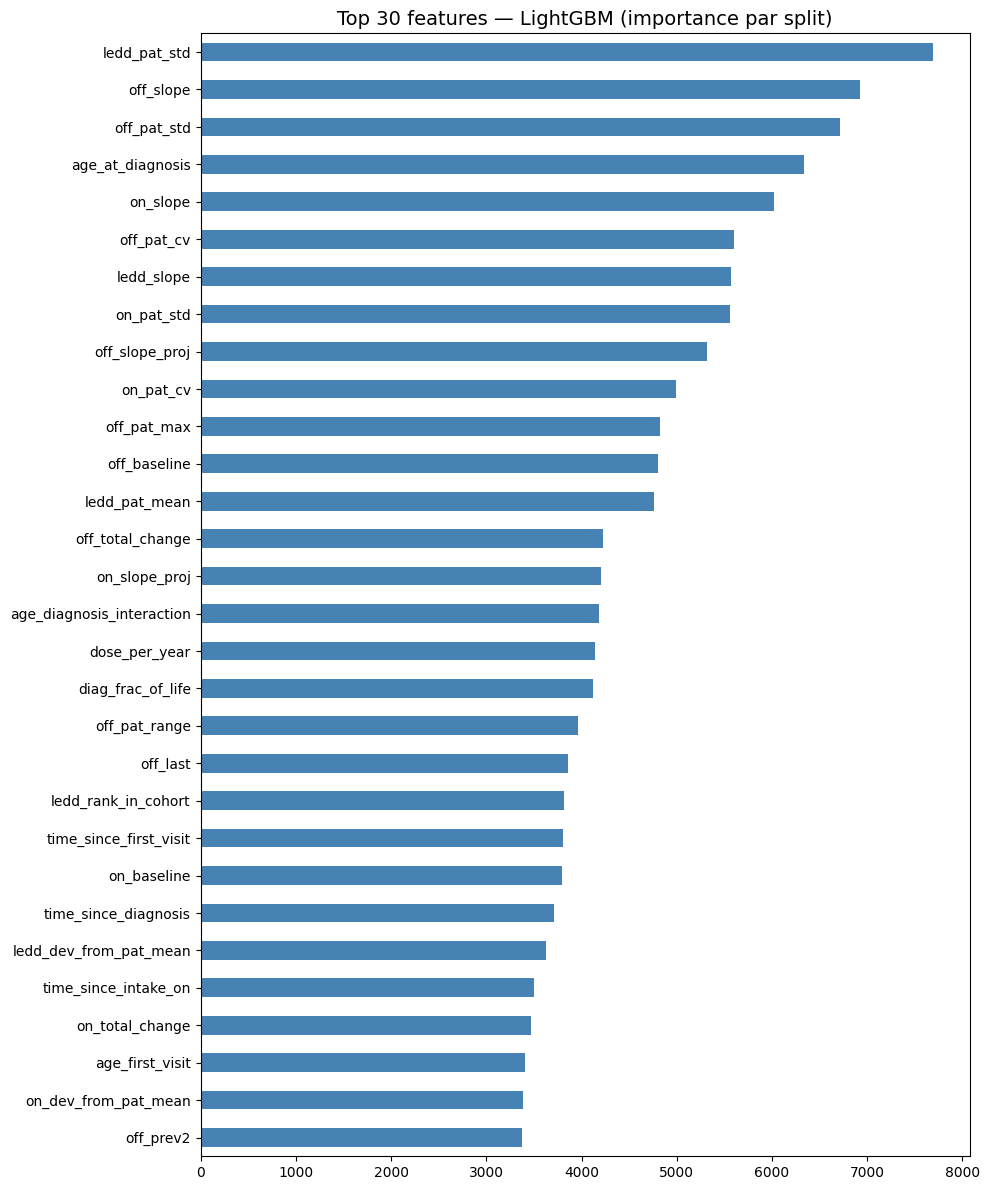


Top 20 :
  ledd_pat_std                        7692
  off_slope                           6929
  off_pat_std                         6712
  age_at_diagnosis                    6331
  on_slope                            6025
  off_pat_cv                          5606
  ledd_slope                          5566
  on_pat_std                          5556
  off_slope_proj                      5321
  on_pat_cv                           4988
  off_pat_max                         4822
  off_baseline                        4801
  ledd_pat_mean                       4758
  off_total_change                    4221
  on_slope_proj                       4203
  age_diagnosis_interaction           4188
  dose_per_year                       4139
  diag_frac_of_life                   4122
  off_pat_range                       3964
  off_last                            3857


In [22]:
# Colonnes avec TE ajouté dans le dernier fold
cols_with_te = list(Xtr_f.columns)

imp_vals = m_lgb.feature_importances_
imp_idx  = np.argsort(imp_vals)[::-1]

top30_names = [cols_with_te[i] for i in imp_idx[:30]]
top30_vals  = imp_vals[imp_idx[:30]]

plt.figure(figsize=(10, 12))
pd.Series(top30_vals[::-1], index=top30_names[::-1]).plot(kind="barh", color="steelblue")
plt.title("Top 30 features — LightGBM (importance par split)", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 20 :")
for n, v in zip(top30_names[:20], top30_vals[:20]):
    print(f"  {n:<35s} {v}")